In [207]:
from pathlib import Path

import pandas as pd
import numpy as np

pd.set_option('display.width', 150)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
previous_loans = pd.read_csv(DATA_DIR / "previous_loans.csv")
bureau = pd.read_csv(DATA_DIR / "bureau.csv")

In [80]:
def leakage_check(df, col, target='target'):
     missing_rate = df.groupby(target)[col].apply(lambda x: x.isna().mean())

     if pd.api.types.is_numeric_dtype(df[col]):
          info = df.groupby(target)[col].describe()
     else: 
          info = df.groupby(target)[col].value_counts(normalize=True)

     return info, missing_rate

В рамках EDA в первую очередь я исключаю столбцы, которые могут привести к утечке данных при обучении классификатора. Критерий: могла ли информация существовать на момент подачи заявления. По названию подозрительно выглядят 4 столбца: 

1. 'days_until_first_overdue' - намекает на событие после выдачи займа
2. 'post_loan_collection_score' - также намекает на событие после "post"
3. 'internal_decision_code' - неясно, фиксируется ли решение на момент заявки или обновляется после

Следующий код проверяет долю nan-значений и распределения значений внутри каждого столбца в разрезе target. Остальные колонки будут проверены при более подробном EDA

In [102]:
suspicious_cols = ['days_until_first_overdue', 'post_loan_collection_score', 'internal_decision_code']

for col in suspicious_cols: 
    print(f"\n### {col} ###\n")
    info, missing_rate = leakage_check(train, col)
    print(info)
    print('\n')
    print(f"Доля пропусков по группам: {missing_rate}")


### days_until_first_overdue ###

         count        mean         std   min    25%    50%      75%     max
target                                                                     
0       3048.0  828.099738  314.847137  30.0  730.0  999.0  1000.00  1002.0
1       1584.0  102.695707  144.773300   1.0   42.0   80.5   119.25   999.0


Доля пропусков по группам: target
0    0.285848
1    0.286486
Name: days_until_first_overdue, dtype: float64

### post_loan_collection_score ###

         count        mean         std   min      25%      50%      75%     max
target                                                                         
0       3234.0  379.679635  166.995151   0.0  265.195  375.125  487.840  1000.0
1       1716.0  699.618124  164.469283  30.5  600.980  706.355  815.505  1000.0


Доля пропусков по группам: target
0    0.242268
1    0.227027
Name: post_loan_collection_score, dtype: float64

### internal_decision_code ###

target  internal_decision_code
0       approved

In [ ]:
# hash_id и client_id - одинаковые сущности

train.groupby('hash_id')['client_id'].nunique().value_counts()

client_id
1    6064
Name: count, dtype: int64

Удаляю следующие столбцы из датафрейма: 

1. days_until_first_overdue 

квартили почти не пересекаются: для target = 0 они лежат в пределах от 730 до 1000 (75 % данных), для target = 1 не превышают 119. значение появляется после наступления просрочки, поэтому исключается как прямая утечка данных

2. post_loan_collection_score

среднее значение target = 1 почти вдвое выше target = 0 при похожей форме распределения (std ~ 165 в обеих группах). судя по названию и величине эффекта признак вычисляется коллекторской системой после выдачи займа, исключаю его по аналогии с прошлой фичей

3. internal_decision_code

89 % строк с target = 1 приходятся на категории, связывающие проблемы с погашением (manual_review_bad, late_flag, collections), у target = 0 эти категории занимают около 13 %. так как отделить момент фиксации категорий нельзя, я исключаю фичу целиком. 

4. cash_id 

является одной сущностью с client_id, не несет никакой дополнительной информации


In [130]:
verdicts = pd.DataFrame({
    'column': ['days_until_first_overdue', 'post_loan_collection_score', 'internal_decision_code', 'hash_id'],
    'verdict': ['drop', 'drop', 'drop', 'drop'],
    'reason': [
        'неизвестно на момент выдачи займа',
        'скор считается после выдачи займа',
        'категории смешаны по смыслу, часть описывает исход после выдачи займа',
        'не несет дополнительной информации'
    ]
})

verdicts

,column,verdict,reason
0,days_until_first_overdue,drop,неизвестно на момент выдачи займа
1,post_loan_collection_score,drop,скор считается после выдачи займа
2,internal_decision_code,drop,"категории смешаны по смыслу, часть описывает и..."
3,hash_id,drop,не несет дополнительной информации


In [135]:
cols_to_drop = verdicts[verdicts['verdict'] == 'drop']['column'].to_list()

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

дополнительное подтверждение - в test.csv все три убранные фичи присутствуют в датасете, но полностью пусты

Далее фичи рассматриваются в порядке убывания их предполагаемой значимости для риска: сначала демографические и финансовые показатели с выраженной связью с target, затем операционные/маркетинговые поля с менее очевидной гипотезой

<function matplotlib.pyplot.show(close=None, block=None)>

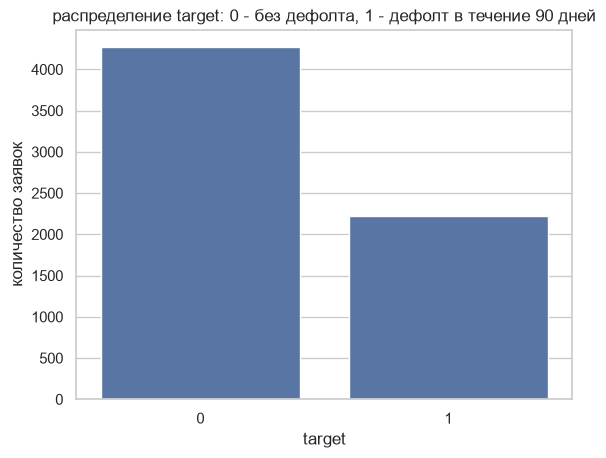

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.countplot(data=train, x='target')

plt.title("распределение target: 0 - без дефолта, 1 - дефолт в течение 90 дней")
plt.xlabel('target')
plt.ylabel('количество заявок')

plt.show

In [153]:
print(train['target'].value_counts(normalize=True))

target
0    0.65783
1    0.34217
Name: proportion, dtype: float64


класс 1 составляет ~ 34 % выборки. умеренный дисбаланс, далее я буду учитывать это при выборе метрики порога 

Регион: region_coefficient_extended, region_coefficient, region, siberia_northern_score

Параметры конкретного займа: loan_amount, loan_term_months, interest_rate, requested_product
Канал/маркетинг: channel, marketing_segment

Демография: age, dependents, education

dependents

гипотеза: больше иждивенцев -> больше нагрузки на бюджет -> больше риска выхода в серьезную просрочку после выдачи займа

In [189]:
def visualization(data, x, target):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(data=data, x=x, ax=axes[0])

    sns.barplot(data=data, x=x, y=target, ax=axes[1])
    axes[0].set_title(f'Распределение {x}')
    axes[1].set_title(f'Доля просрочек по {x}')
    axes[1].set_ylabel(f'доля {target}=1')

    plt.tight_layout()
    plt.show()

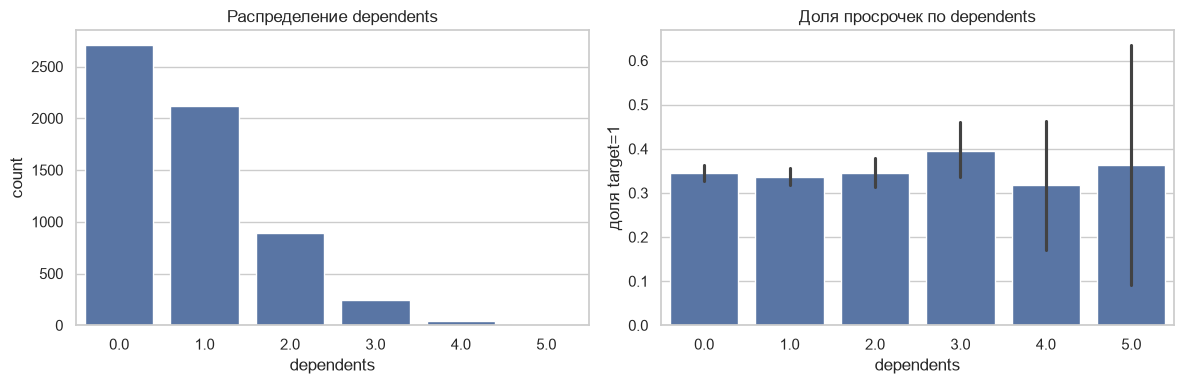

In [190]:
visualization(train, 'dependents', 'target')

Основной тренд отсутствует, значения варьируются от ~ 0.3 до ~ 0.4. Ширина доверительных интервалов показывает, что у dependents = 3,4,5 недостаточное количество наблюдений, чтобы оценка доли просрочек была надежной. Разница в значениях может быть шумом от малого числа наблюдений. Вероятно, это слабая фича, на устойчивость вывода для dependents >= 3 полагаться нельзя из-за малой выборки

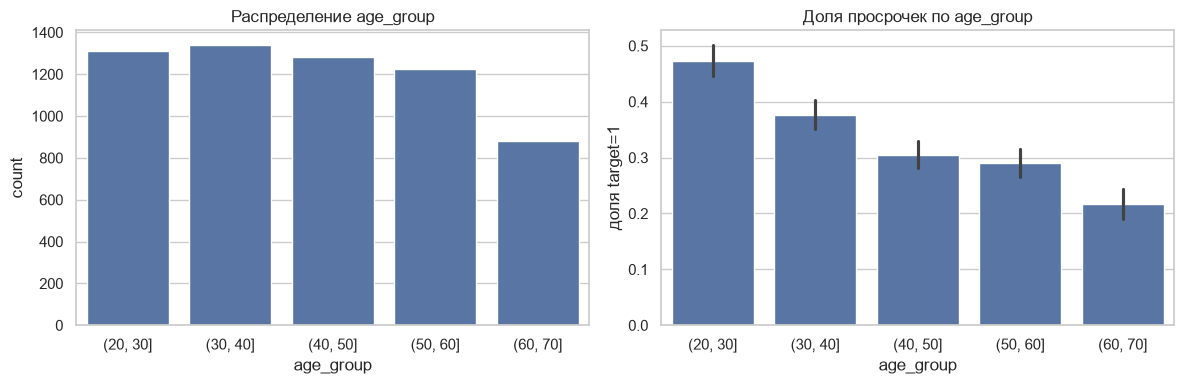

In [191]:
train['age_group'] = pd.cut(train['age'], bins=[20, 30, 40, 50, 60, 70])
visualization(train, 'age_group', 'target')

График описывает устойчивый тренд: чем меньше возраст заемщика, тем больше риска выхода в просрочку. Узкие доверительные интервалы во всех группах говорят о достаточном числе наблюдений и, соответственно, о надежности оценок. Возраст является существенной фичей и надежным предиктором риска. 

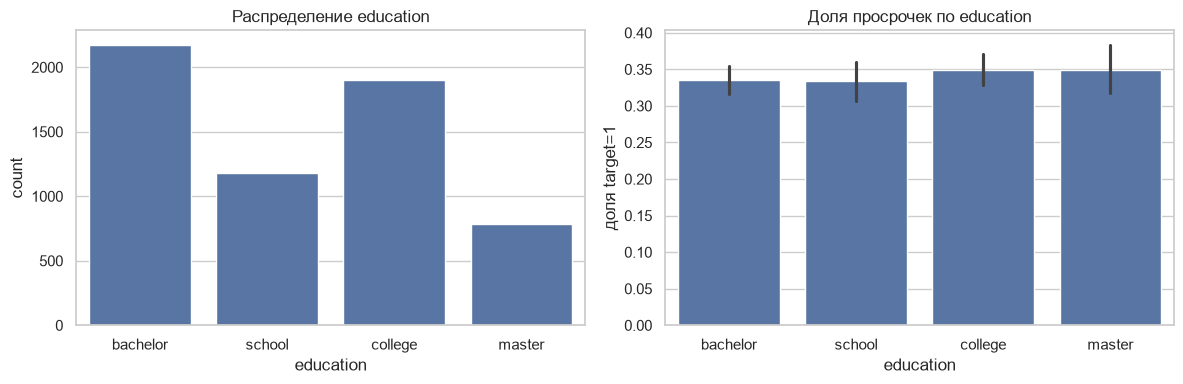

In [192]:
visualization(train, 'education', 'target')

Тренда нет, выборки сопоставимы друг с другом. Категории дают примерно одинаковую долю просрочки, можно считать признак риска слабым или незначительным 

Занятость и доход клиента: employment_type, months_at_job, monthly_income, incoming_amount

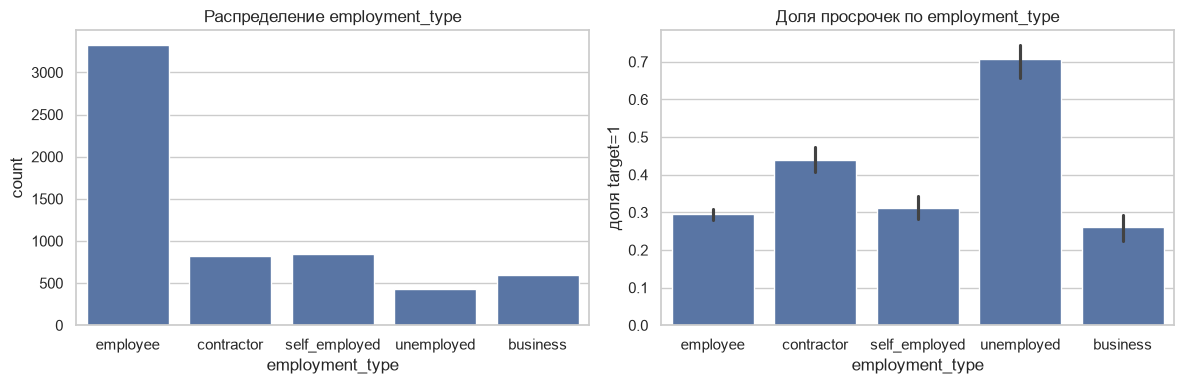

In [193]:
visualization(train, 'employment_type', 'target')

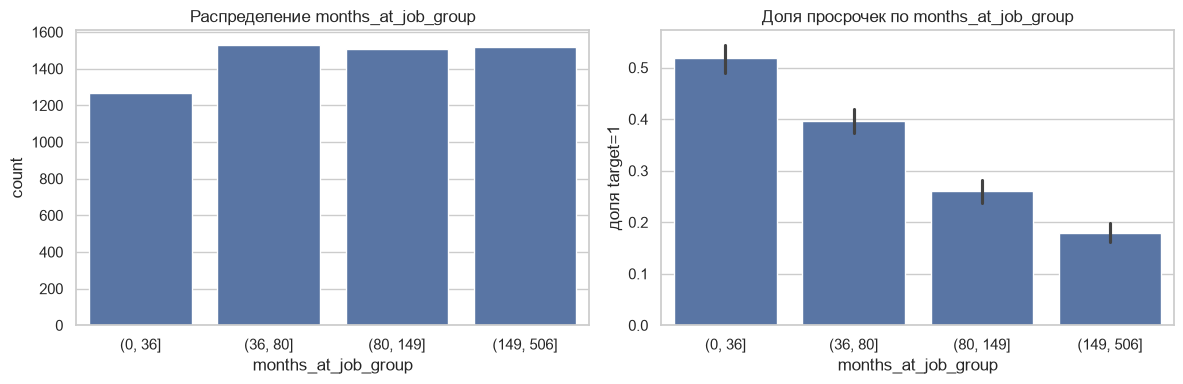

In [194]:
train['months_at_job_group'] = pd.cut(train['months_at_job'], bins=[0, 36, 80, 149, 506]) # разбиение на квартили

visualization(train, 'months_at_job_group', 'target')

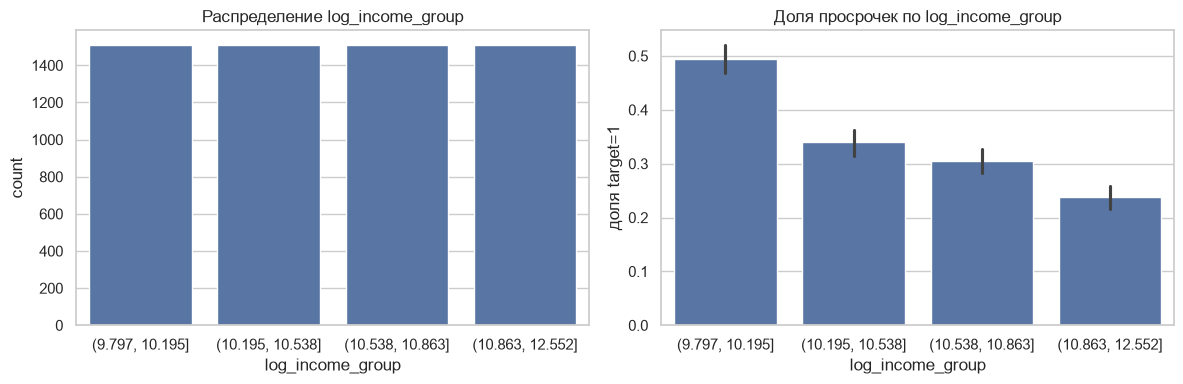

In [208]:
train['log_income'] = np.log1p(train['monthly_income'])
train['log_income_group'] = pd.qcut(train['log_income'], q=4)

visualization(train, 'log_income_group', 'target')

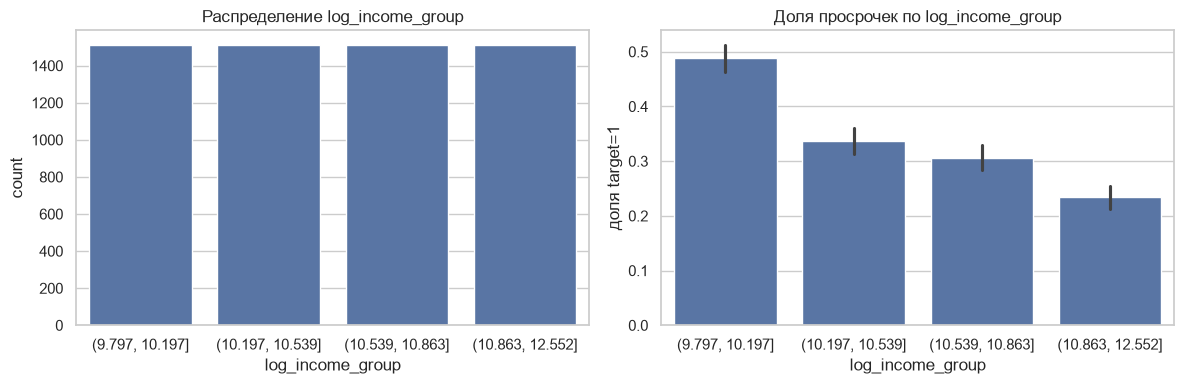

In [210]:
train['log_incoming_amount'] = np.log1p(train['incoming_amount'])
train['log_income_group'] = pd.qcut(train['log_incoming_amount'], q=4)

visualization(train, 'log_income_group', 'target')

In [211]:
train[['monthly_income', 'incoming_amount']].describe()

,monthly_income,incoming_amount
count,6047.000000,6055.000000
mean,42300.330501,42386.646533
std,21759.337138,21867.000385
min,18000.000000,18000.000000
25%,26777.040000,26815.515000
50%,37717.510000,37773.110000
75%,52181.895000,52218.765000
max,282686.980000,282686.980000


In [212]:
train[['monthly_income', 'incoming_amount']].corr()

,monthly_income,incoming_amount
monthly_income,1.0,1.0
incoming_amount,1.0,1.0


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = ["post_loan_collection_score", "days_until_first_overdue"]

x = train[FEATURES]
y = train["target"]

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)
model.fit(x, y)

In [ ]:
test = pd.read_csv(DATA_DIR / "test.csv")
test.head()

In [ ]:
test_pred = model.predict_proba(test[FEATURES])[:, 1]
test_pred[:5]

In [ ]:
submission = pd.DataFrame({"application_id": test["application_id"], "target": test_pred})
submission.to_csv(ROOT / "submission.csv", index=False)
submission.head()